# **COPD Detection from Chest X-Ray Images Using Deep Learning Techniques**

Dataset Links:
- https://www.kaggle.com/datasets/fatemehmehrparvar/lung-disease

#### **Dataset Downloads**

**Google Colab**

In [1]:
!pip install -q kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"efficient8","key":"0e26061c5d5cf73b850e01f7c6575016"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d fatemehmehrparvar/lung-disease

!unzip -q lung-disease.zip

Dataset URL: https://www.kaggle.com/datasets/fatemehmehrparvar/lung-disease
License(s): Attribution 4.0 International (CC BY 4.0)
100% 34.9M/34.9M [00:00<00:00, 201MB/s] 



**Libraries**

In [5]:
import os
import shutil
import warnings
import random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

warnings.filterwarnings('ignore')

#### **Rearranging Dataset Directory**

In [6]:
src_path = r"Lung X-Ray Image/Lung X-Ray Image"
dst_path = r"dataset"

for item in os.listdir(src_path):
    s = os.path.join(src_path, item)
    d = os.path.join(dst_path, item)
    shutil.move(s, d)

# Remove empty inner folder
os.rmdir(src_path)

print("Folder structure fixed successfully!")

Folder structure fixed successfully!


In [7]:
shutil.rmtree("Lung X-Ray Image")

In [8]:
# Count of images in each class

count_of_images_in_lungs = {}
for l in os.listdir(dst_path):
    count_of_images_in_lungs[l] = len(os.listdir(os.path.join(dst_path, l)))

In [9]:
count_of_images_in_lungs

{'Lung_Opacity': 1125, 'Normal': 1250, 'Viral Pneumonia': 1100}

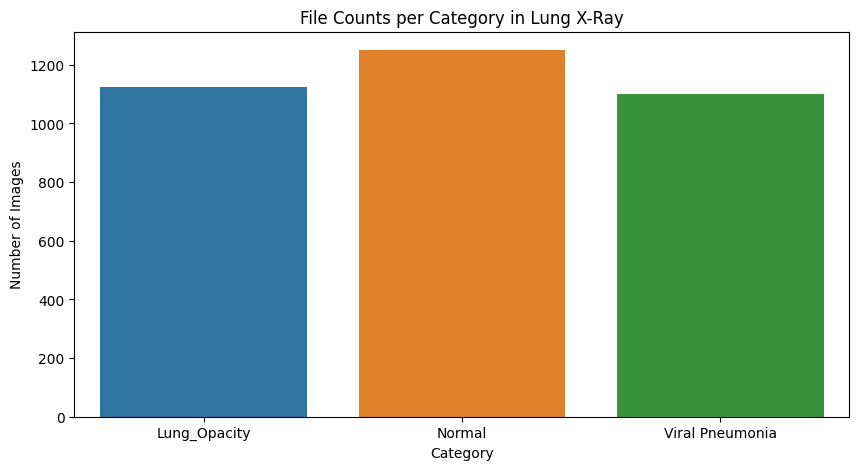

In [10]:
plt.figure(figsize=(10, 5))
sns.barplot(x=count_of_images_in_lungs.keys(), y=count_of_images_in_lungs.values(), hue=count_of_images_in_lungs.keys())
plt.title('File Counts per Category in Lung X-Ray')
plt.ylabel('Number of Images')
plt.xlabel('Category')
plt.show()

**Sample Data Visualization**

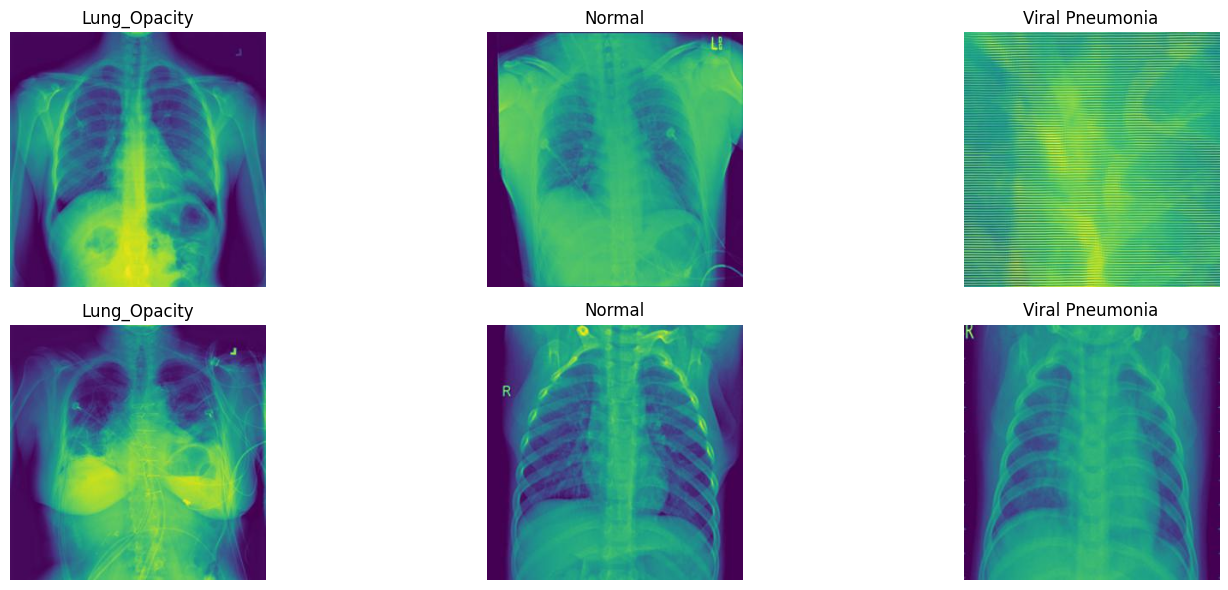

In [11]:
import matplotlib.image as mpimg

categories = os.listdir(dst_path)  # ['Lung_Opacity', 'Normal', 'Viral Pneumonia']
dir_path = 'dataset'

fig, axes = plt.subplots(2, 3, figsize=(16, 6))

for i, category in enumerate(categories):
    folder = os.path.join(dir_path, category)
    images = [f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))]
    sample_imgs = random.sample(images, 2) if len(images) >= 2 else images
    for j, img_name in enumerate(sample_imgs):

        ax = axes[j, i]
        img_path = os.path.join(folder, img_name)
        img = mpimg.imread(img_path)
        ax.imshow(img, cmap='gray')
        ax.set_title(f"{category}")
        ax.axis('off')

    for j in range(len(sample_imgs), 2):
        axes[j, i].axis('off')

plt.tight_layout()
plt.show()


**Train, Test and Validation**

In [12]:
# Paths
source_dir = "dataset"
target_dir = "chest data"

classes = categories

# Create folder structure
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(target_dir, split, cls), exist_ok=True)

# Split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

for cls in classes:
    class_path = os.path.join(source_dir, cls)
    images = [f for f in os.listdir(class_path) if f.endswith(".jpg")]

    random.shuffle(images)

    total = len(images)
    train_end = int(train_ratio * total)
    val_end = train_end + int(val_ratio * total)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    # Copy files
    for img in train_imgs:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(target_dir, "train", cls, img)
        )

    for img in val_imgs:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(target_dir, "val", cls, img)
        )

    for img in test_imgs:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(target_dir, "test", cls, img)
        )

print("Dataset successfully split into Train (70%), Val (15%), Test (15%)")

Dataset successfully split into Train (70%), Val (15%), Test (15%)


**Data after train, test and validation split**

In [13]:
train_parent_dir = r"chest data/train"
print("Count of Images for each class in train directory")
for f in classes:
    count_of_images = len(os.listdir(os.path.join(train_parent_dir, f)))
    print(f"{f} has {count_of_images} images")

Count of Images for each class in train directory
Lung_Opacity has 787 images
Normal has 875 images
Viral Pneumonia has 770 images


In [14]:
val_parent_dir = "chest data/val"
print("Count of Images for each class in val directory")
for f in classes:
    count_of_images = len(os.listdir(os.path.join(val_parent_dir, f)))
    print(f"{f} has {count_of_images} images")

Count of Images for each class in val directory
Lung_Opacity has 168 images
Normal has 187 images
Viral Pneumonia has 165 images


In [15]:
test_parent_dir = "chest data/test"
print("Count of Images for each class in test directory")
for f in classes:
    count_of_images = len(os.listdir(os.path.join(test_parent_dir, f)))
    print(f"{f} has {count_of_images} images")

Count of Images for each class in test directory
Lung_Opacity has 170 images
Normal has 188 images
Viral Pneumonia has 165 images


#### **Data Augmentation**

In [16]:
train_dir = "chest data/train"
val_dir = "chest data/val"
test_dir = "chest data/test"

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [18]:
img_dims = (224, 224)
batch_size = 32

In [19]:
train_data = ImageDataGenerator(
    rescale=1./255,
    rotation_range=45,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

train_generator = train_data.flow_from_directory(
    directory=train_dir,
    target_size= img_dims,
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical'
)

Found 2432 images belonging to 3 classes.


In [20]:
train_generator.class_indices

{'Lung_Opacity': 0, 'Normal': 1, 'Viral Pneumonia': 2}

In [21]:
val_test_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_test_datagen.flow_from_directory(
    directory=val_dir,
    target_size=img_dims,
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical'
)

Found 520 images belonging to 3 classes.


In [22]:
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=img_dims,
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 523 images belonging to 3 classes.


## **Class Imbalance Check**

In [23]:
import numpy as np
from collections import Counter

# Get class labels
class_labels = train_generator.class_indices
print("Class Labels:", class_labels)

# Count samples
counts = Counter(train_generator.classes)

print("\nClass Distribution:")
for class_name, idx in class_labels.items():
    print(f"{class_name}: {counts[idx]}")

Class Labels: {'Lung_Opacity': 0, 'Normal': 1, 'Viral Pneumonia': 2}

Class Distribution:
Lung_Opacity: 787
Normal: 875
Viral Pneumonia: 770


In [24]:
counts_list = np.array(list(counts.values()))

imbalance_ratio = counts_list.max() / counts_list.min()
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}")


Imbalance Ratio: 1.14


In [25]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print("\nClass Weights:", class_weights)


Class Weights: {0: np.float64(1.0300720033883948), 1: np.float64(0.9264761904761905), 2: np.float64(1.0528138528138529)}


## **Models**

In [26]:
epochs = 10
allresults = []

In [27]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.3, patience=3)
]

#### **CNN Model**

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(512, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dropout(0.2),

    Dense(len(train_generator.class_indices.keys()), activation='softmax'),
])

In [29]:
from tensorflow.keras.metrics import Precision, Recall, AUC

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall'), AUC(name='auc')]
)

In [30]:
cnn_history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 57s 519ms/step - accuracy: 0.5576 - auc: 0.7263 - loss: 2.0418 - precision: 0.5612 - recall: 0.5469 - val_accuracy: 0.3231 - val_auc: 0.5182 - val_loss: 3.4080 - val_precision: 0.3231 - val_recall: 0.3231 - learning_rate: 0.0010
Epoch 2/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 32s 416ms/step - accuracy: 0.6164 - auc: 0.8002 - loss: 1.1202 - precision: 0.6278 - recall: 0.5950 - val_accuracy: 0.3423 - val_auc: 0.5798 - val_loss: 1.7785 - val_precision: 0.3423 - val_recall: 0.3423 - learning_rate: 0.0010
Epoch 3/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 34s 443ms/step - accuracy: 0.6826 - auc: 0.8563 - loss: 0.8038 - precision: 0.7023 - recall: 0.6517 - val_accuracy: 0.3231 - val_auc: 0.7131 - val_loss: 1.9992 - val_precision: 0.3231 - val_recall: 0.3231 - learning_rate: 0.0010
Epoch 4/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 32s 419ms/step - accuracy: 0.6970 - auc: 0.8768 - loss: 0.6960 - precision: 0.7202 - recall: 0.6616 - val_accuracy: 0.3250 - val_auc: 0.5671 - val_loss: 3.3813 -

In [32]:
cnn_test_loss, cnn_test_accuracy, cnn_test_precision, cnn_test_recall, cnn_test_auc = cnn_model.evaluate(test_generator)
print(f"Test Accuracy: {cnn_test_accuracy * 100:.2f}%")

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.8489 - auc: 0.9586 - loss: 0.3899 - precision: 0.8710 - recall: 0.8260
Test Accuracy: 84.89%


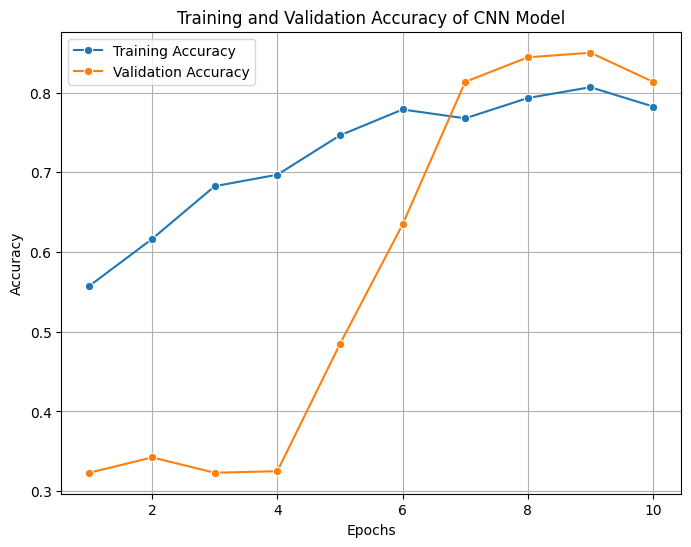

In [33]:
cnn_df = pd.DataFrame({
    "Epoch": range(1, len(cnn_history.history['accuracy']) + 1),
    "Training Accuracy": cnn_history.history['accuracy'],
    "Validation Accuracy": cnn_history.history['val_accuracy']
})

# Melt DataFrame for Seaborn
cnn_df_melted = cnn_df.melt(id_vars="Epoch",
                   value_vars=["Training Accuracy", "Validation Accuracy"],
                   var_name="Type",
                   value_name="Accuracy")

plt.figure(figsize=(8,6))
sns.lineplot(data=cnn_df_melted, x="Epoch", y="Accuracy", hue="Type", marker="o")
plt.title('Training and Validation Accuracy of CNN Model')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend(title="")
plt.show()

In [34]:
cnn_y_pred = cnn_model.predict(test_generator, steps=test_generator.samples // test_generator.batch_size + 1)
cnn_y_pred_classes = np.argmax(cnn_y_pred, axis=1)

# True labels
cnn_y_true = test_generator.classes

17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step


Accuracy: 0.849
Precision: 0.861
Recall: 0.848
F1 Score: 0.851


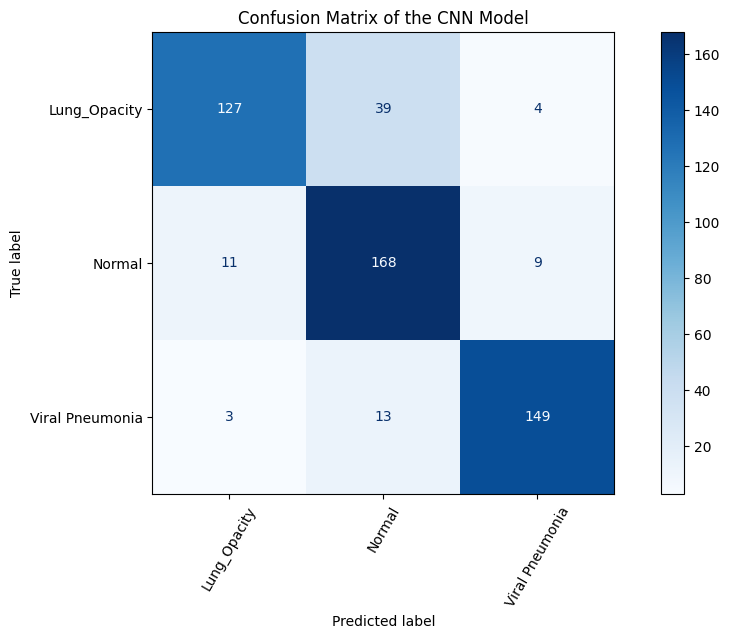

In [37]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
cnn_cm = confusion_matrix(cnn_y_true, cnn_y_pred_classes)

# Calculate metrics (macro average for multiclass)
cnn_accuracy = accuracy_score(cnn_y_true, cnn_y_pred_classes)
cnn_precision = precision_score(cnn_y_true, cnn_y_pred_classes, average='macro')
cnn_recall = recall_score(cnn_y_true, cnn_y_pred_classes, average='macro')
cnn_f1 = f1_score(cnn_y_true, cnn_y_pred_classes, average='macro')

print(f'Accuracy: {cnn_accuracy:.3f}')
print(f'Precision: {cnn_precision:.3f}')
print(f'Recall: {cnn_recall:.3f}')
print(f'F1 Score: {cnn_f1:.3f}')

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(12, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cnn_cm, display_labels=train_generator.class_indices.keys())
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.xticks(rotation=60)
plt.title('Confusion Matrix of the CNN Model')
plt.show()

In [38]:
cnn_results = {
    "Model Name": "CNN",
    "Accuracy": cnn_accuracy,
    "Precision": cnn_precision,
    "Recall": cnn_recall,
    "F1 Score": cnn_f1
}

allresults.append(cnn_results)

#### **MobileNetV2**

In [39]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

In [40]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

# Final model
mob_model = Model(inputs=base_model.input, outputs=predictions)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [41]:
mob_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall'), AUC(name='auc')]
)

In [42]:
mob_history = mob_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 72s 696ms/step - accuracy: 0.7644 - auc: 0.9099 - loss: 0.5695 - precision: 0.7914 - recall: 0.7130 - val_accuracy: 0.8500 - val_auc: 0.9529 - val_loss: 0.4168 - val_precision: 0.8620 - val_recall: 0.8288 - learning_rate: 0.0010
Epoch 2/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 31s 407ms/step - accuracy: 0.8507 - auc: 0.9597 - loss: 0.3700 - precision: 0.8603 - recall: 0.8380 - val_accuracy: 0.8654 - val_auc: 0.9643 - val_loss: 0.3554 - val_precision: 0.8730 - val_recall: 0.8596 - learning_rate: 0.0010
Epoch 3/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 31s 403ms/step - accuracy: 0.8676 - auc: 0.9647 - loss: 0.3433 - precision: 0.8712 - recall: 0.8540 - val_accuracy: 0.8558 - val_auc: 0.9625 - val_loss: 0.3614 - val_precision: 0.8642 - val_recall: 0.8442 - learning_rate: 0.0010
Epoch 4/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 30s 389ms/step - accuracy: 0.8635 - auc: 0.9679 - loss: 0.3281 - precision: 0.8699 - recall: 0.8553 - val_accuracy: 0.8692 - val_auc: 0.9671 - val_loss: 0.3376 -

#### **Fine Tuning MobileNetV2**

In [43]:
from tensorflow.keras.optimizers import Adam

for layer in base_model.layers[-30:]:
    layer.trainable = True

mob_model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

mob_history = mob_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 55s 502ms/step - accuracy: 0.8047 - loss: 0.4735 - val_accuracy: 0.8885 - val_loss: 0.3066 - learning_rate: 1.0000e-05
Epoch 2/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 30s 398ms/step - accuracy: 0.8466 - loss: 0.3750 - val_accuracy: 0.8904 - val_loss: 0.3161 - learning_rate: 1.0000e-05
Epoch 3/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 30s 389ms/step - accuracy: 0.8639 - loss: 0.3444 - val_accuracy: 0.8962 - val_loss: 0.2956 - learning_rate: 1.0000e-05
Epoch 4/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 31s 405ms/step - accuracy: 0.8655 - loss: 0.3317 - val_accuracy: 0.8962 - val_loss: 0.2960 - learning_rate: 3.0000e-06
Epoch 5/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 29s 385ms/step - accuracy: 0.8721 - loss: 0.3279 - val_accuracy: 0.9000 - val_loss: 0.2962 - learning_rate: 3.0000e-06


In [44]:
mob_test_loss, mob_test_accuracy = mob_model.evaluate(test_generator)
print(f"Test Accuracy: {mob_test_accuracy * 100:.2f}%")

17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 715ms/step - accuracy: 0.8776 - loss: 0.3273
Test Accuracy: 87.76%


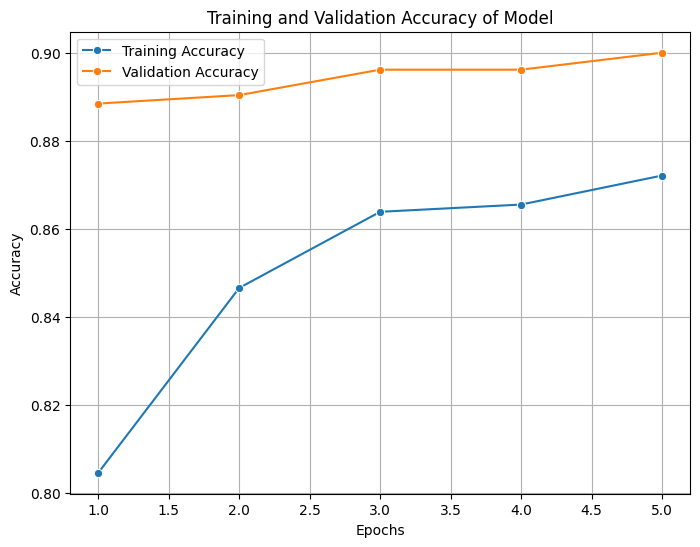

In [45]:
df = pd.DataFrame({
    "Epoch": range(1, len(mob_history.history['accuracy']) + 1),
    "Training Accuracy": mob_history.history['accuracy'],
    "Validation Accuracy": mob_history.history['val_accuracy']
})

# Melt DataFrame for Seaborn
df_melted = df.melt(id_vars="Epoch",
                   value_vars=["Training Accuracy", "Validation Accuracy"],
                   var_name="Type",
                   value_name="Accuracy")

plt.figure(figsize=(8,6))
sns.lineplot(data=df_melted, x="Epoch", y="Accuracy", hue="Type", marker="o")
plt.title('Training and Validation Accuracy of Model')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend(title="")
plt.show()

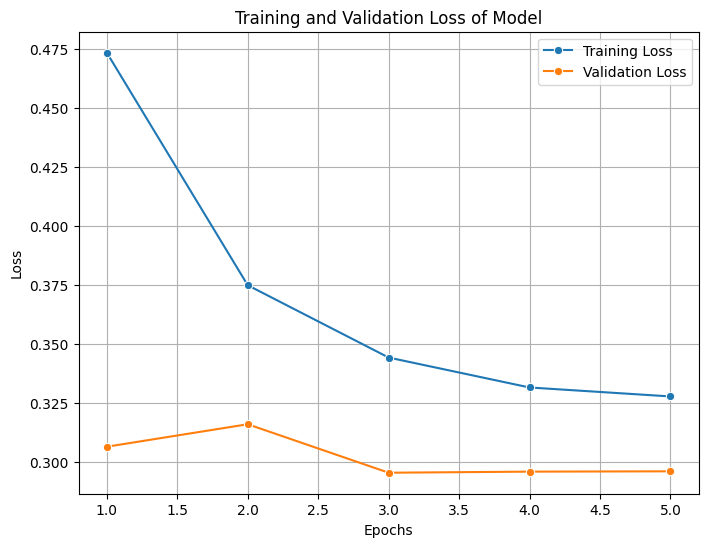

In [46]:
df_loss = pd.DataFrame({
    "Epoch": range(1, len(mob_history.history['loss']) + 1),
    "Training Loss": mob_history.history['loss'],
    "Validation Loss": mob_history.history['val_loss']
})

# Melt DataFrame for Seaborn
df_loss_melted = df_loss.melt(id_vars="Epoch",
                              value_vars=["Training Loss", "Validation Loss"],
                              var_name="Type",
                              value_name="Loss")

# Plot loss
plt.figure(figsize=(8,6))
sns.lineplot(data=df_loss_melted, x="Epoch", y="Loss", hue="Type", marker="o")
plt.title('Training and Validation Loss of Model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend(title="")
plt.show()

In [47]:
# Predict on test set
mob_y_pred = mob_model.predict(test_generator, steps=test_generator.samples // test_generator.batch_size + 1)
mob_y_pred_classes = np.argmax(mob_y_pred, axis=1)

# True labels
mob_y_true = test_generator.classes

17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 308ms/step


In [48]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

mob_cm = confusion_matrix(mob_y_true, mob_y_pred_classes)

# Calculate metrics (macro average for multiclass)
mob_accuracy = accuracy_score(mob_y_true, mob_y_pred_classes)
mob_precision = precision_score(mob_y_true, mob_y_pred_classes, average='macro')
mob_recall = recall_score(mob_y_true, mob_y_pred_classes, average='macro')
mob_f1 = f1_score(mob_y_true, mob_y_pred_classes, average='macro')

print(f'Accuracy: {mob_accuracy:.3f}')
print(f'Precision: {mob_precision:.3f}')
print(f'Recall: {mob_recall:.3f}')
print(f'F1 Score: {mob_f1:.3f}')

Accuracy: 0.878
Precision: 0.890
Recall: 0.877
F1 Score: 0.880


In [49]:
mob_results = {
    "Model Name": "MobileNetV2",
    "Accuracy": mob_accuracy,
    "Precision": mob_precision,
    "Recall": mob_recall,
    "F1 Score": mob_f1
}

allresults.append(mob_results)

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Predict on test set
y_pred = mob_model.predict(test_generator, steps=test_generator.samples // test_generator.batch_size + 1)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = test_generator.classes

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step


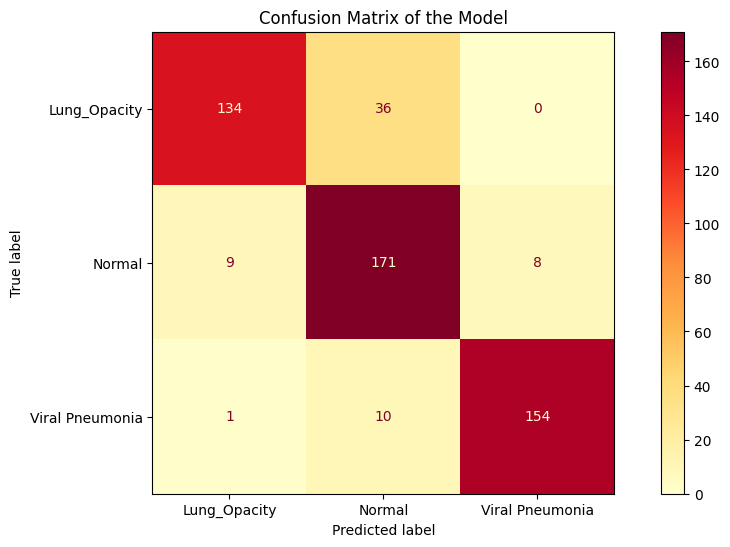

In [51]:
cm = confusion_matrix(y_true, y_pred_classes)

# Labels from the generator
class_labels = train_generator.class_indices.keys()
display_labels = class_labels

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(12, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot(cmap=plt.cm.YlOrRd, ax=ax)

plt.title('Confusion Matrix of the Model')
plt.show()

#### **VGG16**

In [52]:
from tensorflow.keras.applications import VGG16

In [53]:
vgg16_base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the convolutional base
vgg16_base_model.trainable = False

# Build your model
vgg16_model = Sequential([
    vgg16_base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [54]:
vgg16_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall'), AUC(name='auc')]
)

In [55]:
vgg16_history = vgg16_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 60s 549ms/step - accuracy: 0.7138 - auc: 0.8412 - loss: 0.9720 - precision: 0.7310 - recall: 0.6793 - val_accuracy: 0.8385 - val_auc: 0.9492 - val_loss: 0.4250 - val_precision: 0.8569 - val_recall: 0.8173 - learning_rate: 0.0010
Epoch 2/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 36s 477ms/step - accuracy: 0.8211 - auc: 0.9405 - loss: 0.4538 - precision: 0.8360 - recall: 0.7924 - val_accuracy: 0.8635 - val_auc: 0.9665 - val_loss: 0.3383 - val_precision: 0.8619 - val_recall: 0.8519 - learning_rate: 0.0010
Epoch 3/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 36s 479ms/step - accuracy: 0.8318 - auc: 0.9498 - loss: 0.4163 - precision: 0.8480 - recall: 0.8121 - val_accuracy: 0.8596 - val_auc: 0.9671 - val_loss: 0.3393 - val_precision: 0.8674 - val_recall: 0.8558 - learning_rate: 0.0010
Epoch 4/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 35s 465ms/step - accuracy: 0.8491 - auc: 0.9603 - loss: 0.3677 - precision: 0.8567 - recall: 0.8306 - val_accuracy: 0.8808 - val_auc: 0.9721 - val_loss: 0.3067 -

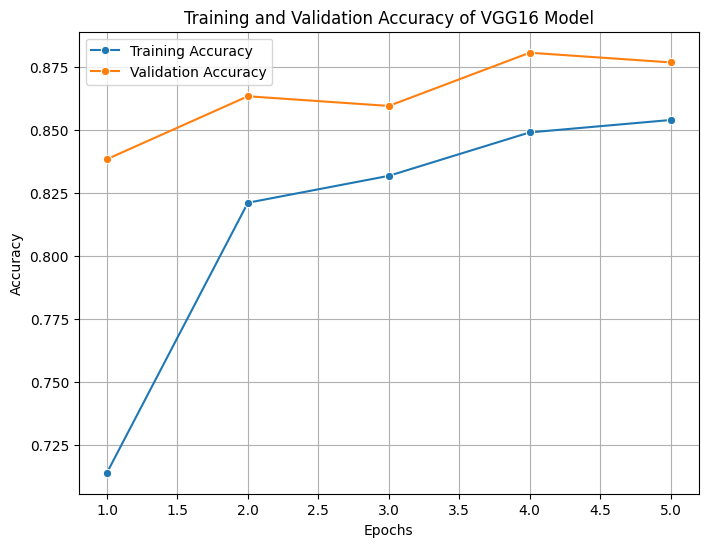

In [56]:
vgg16_df = pd.DataFrame({
    "Epoch": range(1, len(vgg16_history.history['accuracy']) + 1),
    "Training Accuracy": vgg16_history.history['accuracy'],
    "Validation Accuracy": vgg16_history.history['val_accuracy']
})

# Melt DataFrame for Seaborn
vgg16_df_melted = vgg16_df.melt(id_vars="Epoch",
                   value_vars=["Training Accuracy", "Validation Accuracy"],
                   var_name="Type",
                   value_name="Accuracy")

plt.figure(figsize=(8,6))
sns.lineplot(data=vgg16_df_melted, x="Epoch", y="Accuracy", hue="Type", marker="o")
plt.title('Training and Validation Accuracy of VGG16 Model')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend(title="")
plt.show()

In [57]:
vgg16_y_pred = vgg16_model.predict(test_generator, steps=test_generator.samples // test_generator.batch_size + 1)
vgg16_y_pred_classes = np.argmax(vgg16_y_pred, axis=1)

# True labels
vgg16_y_true = test_generator.classes

17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 591ms/step


Accuracy: 0.809
Precision: 0.812
Recall: 0.811
F1 Score: 0.811


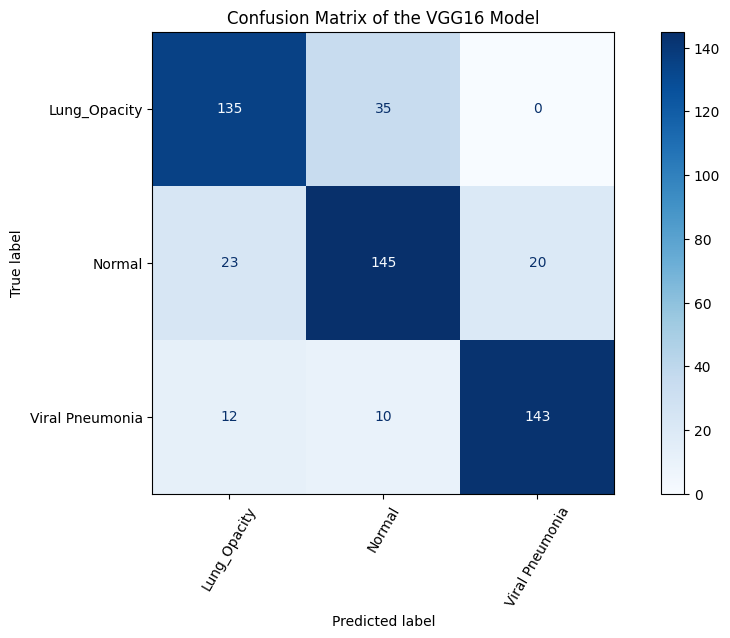

In [58]:
vgg16_cm = confusion_matrix(vgg16_y_true, vgg16_y_pred_classes)

# Calculate metrics (macro average for multiclass)
vgg16_accuracy = accuracy_score(vgg16_y_true, vgg16_y_pred_classes)
vgg16_precision = precision_score(vgg16_y_true, vgg16_y_pred_classes, average='macro')
vgg16_recall = recall_score(vgg16_y_true, vgg16_y_pred_classes, average='macro')
vgg16_f1 = f1_score(vgg16_y_true, vgg16_y_pred_classes, average='macro')

print(f'Accuracy: {vgg16_accuracy:.3f}')
print(f'Precision: {vgg16_precision:.3f}')
print(f'Recall: {vgg16_recall:.3f}')
print(f'F1 Score: {vgg16_f1:.3f}')

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(12, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=vgg16_cm, display_labels=train_generator.class_indices.keys())
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.xticks(rotation=60)
plt.title('Confusion Matrix of the VGG16 Model')
plt.show()

In [59]:
# Create a dictionary for the row
vgg16_results = {
    "Model Name": "VGG16",
    "Accuracy": vgg16_accuracy,
    "Precision": vgg16_precision,
    "Recall": vgg16_recall,
    "F1 Score": vgg16_f1
}

allresults.append(vgg16_results)

## **Plots**

In [60]:
results_df = pd.DataFrame(allresults)
results_df

,Model Name,Accuracy,Precision,Recall,F1 Score
0,CNN,0.848948,0.861366,0.847902,0.850522
1,MobileNetV2,0.877629,0.889730,0.877048,0.879948
2,VGG16,0.808795,0.811525,0.810687,0.811088


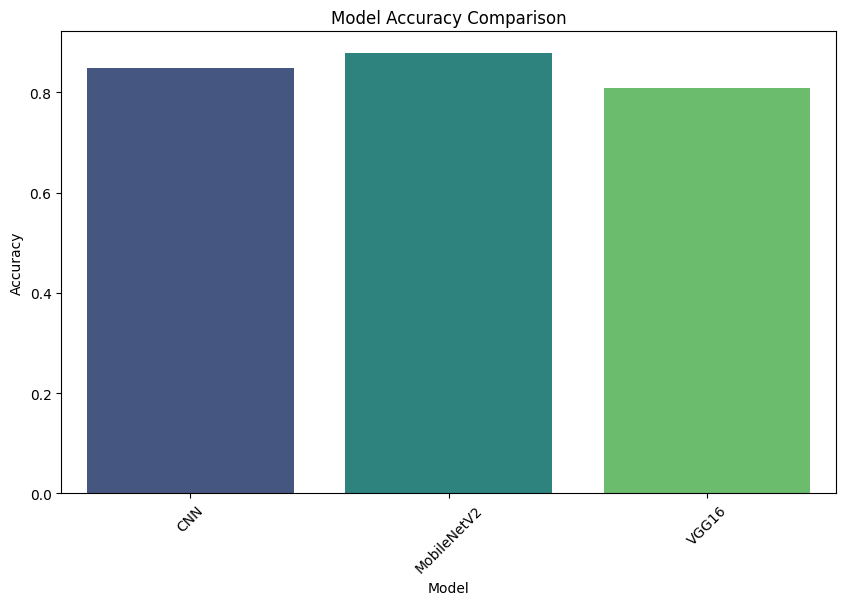

In [61]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model Name', y='Accuracy', data=results_df, palette='viridis', hue='Model Name')
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.ylabel('Accuracy')
plt.show()

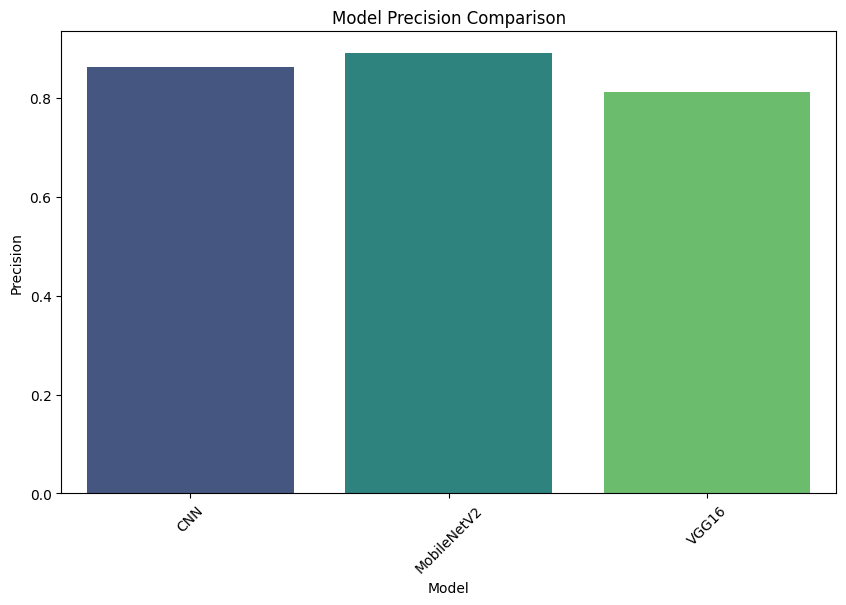

In [62]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model Name', y='Precision', data=results_df, palette='viridis', hue='Model Name')
plt.title('Model Precision Comparison')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.ylabel('Precision')
plt.show()

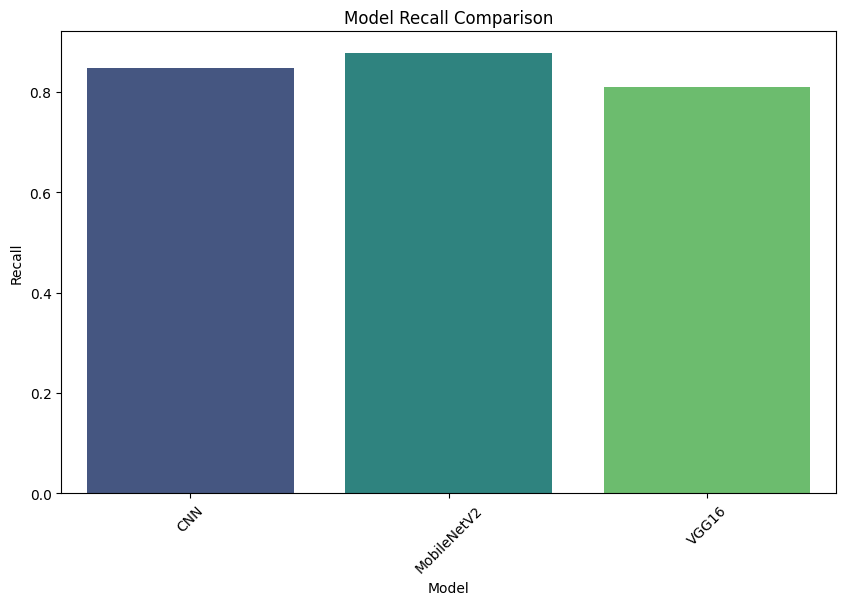

In [63]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model Name', y='Recall', data=results_df, palette='viridis', hue='Model Name')
plt.title('Model Recall Comparison')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.ylabel('Recall')
plt.show()

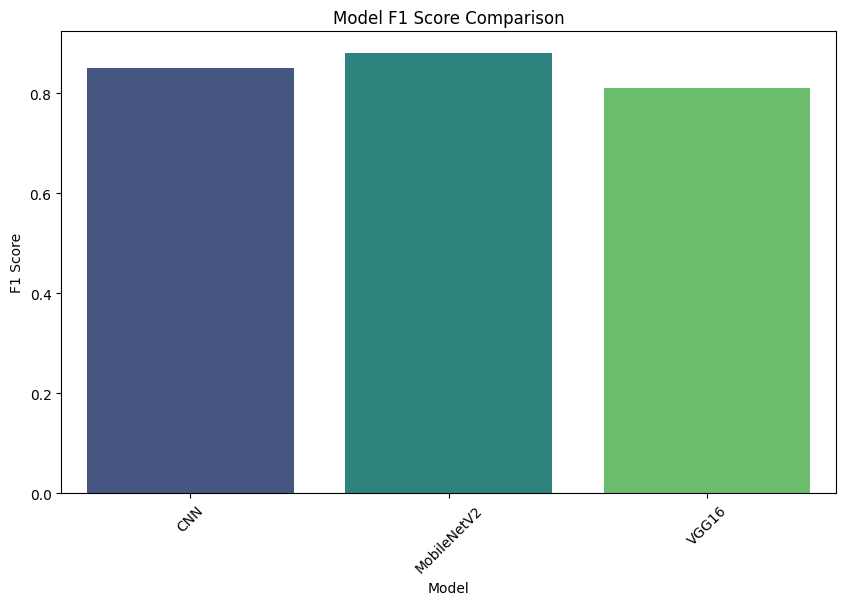

In [64]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model Name', y='F1 Score', data=results_df, palette='viridis', hue='Model Name')
plt.title('Model F1 Score Comparison')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.ylabel('F1 Score')
plt.show()

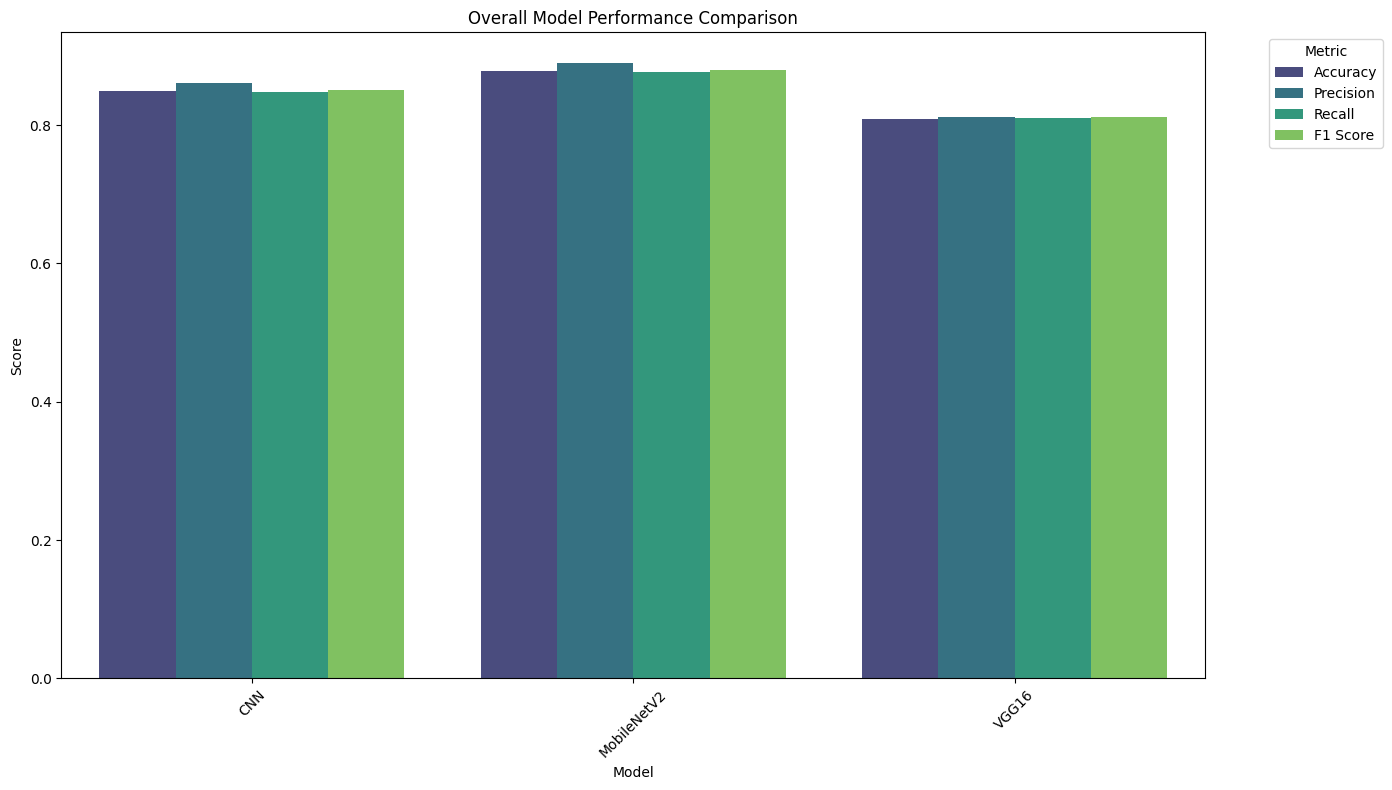

In [65]:
results_df_melted = results_df.melt(id_vars='Model Name', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 8))
sns.barplot(x='Model Name', y='Score', hue='Metric', data=results_df_melted, palette='viridis')
plt.title('Overall Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## **Test Predictions**

In [66]:
from tensorflow.keras.preprocessing import image

# 1. Choose the best model based on Accuracy
best_model_row = results_df.loc[results_df['Accuracy'].idxmax()]
best_model_name = best_model_row['Model Name']

print(f"Best model based on Accuracy: {best_model_name}")

# Retrieve the actual model object
if best_model_name == "CNN":
    selected_model = cnn_model
elif best_model_name == "MobileNetV2":
    selected_model = mob_model
elif best_model_name == "VGG16":
    selected_model = vgg16_model
else:
    raise ValueError(f"Unknown best model name: {best_model_name}")

Best model based on Accuracy: MobileNetV2


In [67]:
idx_to_class = {v: k for k, v in train_generator.class_indices.items()}

test_image_paths = []
test_true_labels_indices = []

for class_name in os.listdir(test_dir):
    class_path = os.path.join(test_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            test_image_paths.append(os.path.join(class_path, img_name))
            test_true_labels_indices.append(train_generator.class_indices[class_name])

random_indices = random.sample(range(len(test_image_paths)), 3)
selected_image_paths = [test_image_paths[i] for i in random_indices]
selected_true_labels = [test_true_labels_indices[i] for i in random_indices]

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


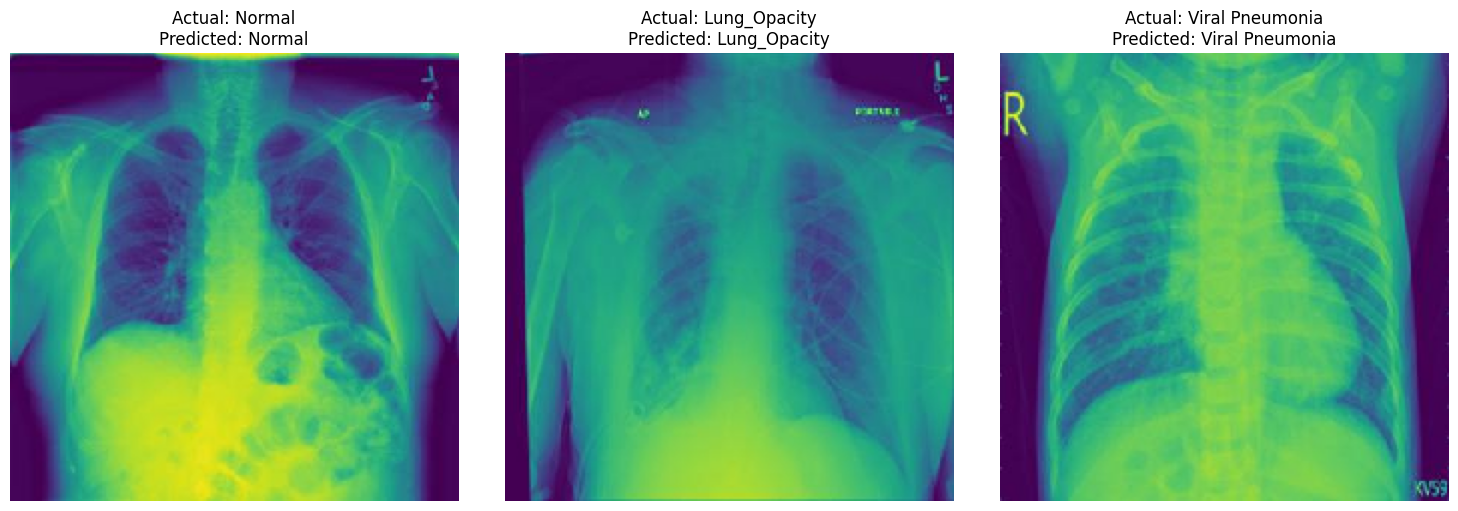

In [68]:
plt.figure(figsize=(15, 5))
for i, img_path in enumerate(selected_image_paths):

    img = image.load_img(img_path, target_size=img_dims)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    # Make prediction
    prediction = selected_model.predict(img_array)
    predicted_class_idx = np.argmax(prediction)
    predicted_class_name = idx_to_class[predicted_class_idx]
    actual_class_name = idx_to_class[selected_true_labels[i]]

    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Actual: {actual_class_name}\nPredicted: {predicted_class_name}")
    plt.axis('off')

plt.tight_layout()
plt.show()